In [1]:
# =============================================Import dependencies==============================================================
import numpy as np
import random
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision.models as models
from torch.optim import Adam, AdamW
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import time
import copy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from matplotlib import pyplot as plt
plt.rcParams.update({'figure.figsize': (20.0, 8.0)})
plt.rcParams.update({'font.size': 14})
from sklearn import decomposition
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d.axes3d import Axes3D 
pd.set_option('display.max_columns', None)
import os
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import palettable
import seaborn as sns
from sklearn.metrics import accuracy_score

In [2]:
#======================================== import the related dependencies=======================================================
import numpy as np
import random
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision.models as models
from torch.optim import Adam, AdamW
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import time
import copy
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
plt.rcParams.update({'figure.figsize': (12.0, 8.0)})
plt.rcParams.update({'font.size': 14})
from sklearn.metrics import accuracy_score

In [3]:
#=============================In order to ensure the reproduibility, set seed===================================================
def same_seeds(seed):
    # Python built-in random module
    random.seed(seed)
    # Numpy seed
    np.random.seed(seed)
    # Torch seed
    torch.manual_seed(seed)
    # Cuda seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
same_seeds(19530615)


In [4]:
#Obtain the working path in order to check that if it is the target working path
os.getcwd()  

# os.chdir('C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\N\\Vcharge20210709')  
# path = 'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\N\\Vcharge20210709'
# path = os.getcwd()


'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\preprocess data\\experiments_C'

In [5]:
def read_txt(path):
    datalist = []
    for i in os.listdir(path):
        if os.path.splitext(i)[1] == '.txt':     #select .txt files and add them into datalist
            datalist.append(i)
    
    df = pd.DataFrame()
    for txt in datalist:
        data_path = os.path.join(path,txt)    #generate path for each txt file
        df_txt = pd.read_table(data_path,index_col = False) # read txt file and do no take first column as the index
        df = pd.concat([df,df_txt],axis=0, ignore_index=True)     # concate file axis means concate vertically, other concate vertically. ignore_index=True ,ignore original index
       
    return df

In [6]:
path = 'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\N\\Vcharge20210218'
data_Vcharge20210218= read_txt(path)
#=======================preprocessing of data_Vcharge20210218===================================================================
data_Vcharge20210218=data_Vcharge20210218.drop(['RackID','TS','Online', 'RelayStatus','TotVHighFault','TotVLowFault','ModuleCount'], axis=1)

Total_num_racks = 12
Rack_0_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 0]
Rack_1_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 1]
Rack_2_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 2]
Rack_3_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 3]
Rack_4_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 4]
Rack_5_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 5]
Rack_6_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 6]
Rack_7_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 7]
Rack_8_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 8]
Rack_9_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 9]
Rack_10_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 10]
Rack_11_data_Vcharge20210218 = data_Vcharge20210218[data_Vcharge20210218.index % Total_num_racks == 11]



Negative_samples_data_Vcharge20210218 = pd.concat([Rack_0_data_Vcharge20210218,Rack_1_data_Vcharge20210218,Rack_2_data_Vcharge20210218,
                              Rack_3_data_Vcharge20210218,Rack_4_data_Vcharge20210218,
                              Rack_5_data_Vcharge20210218,Rack_6_data_Vcharge20210218,
                              Rack_7_data_Vcharge20210218,Rack_9_data_Vcharge20210218,
                              Rack_10_data_Vcharge20210218,Rack_11_data_Vcharge20210218,],axis=0)

Positive_samples_data_Vcharge20210218= Rack_8_data_Vcharge20210218

C:\Users\XUWANG~1\AppData\Local\Temp/ipykernel_21564/3320135836.py:2: DtypeWarning: Columns (27) have mixed types.Specify dtype option on import or set low_memory=False.
  data_Vcharge20210218= read_txt(path)


In [7]:
path = 'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\N\\Vcharge20210709'
data_Vcharge20210709= read_txt(path)

#=======================preprocessing of data_Vcharge20210709===================================================================
data_Vcharge20210709 = data_Vcharge20210709.drop(['RackID','TS','Online', 'RelayStatus','TotVHighFault','TotVLowFault','ModuleCount'], axis=1)
Negative_samples_data_Vcharge20210709 = data_Vcharge20210709

C:\Users\XUWANG~1\AppData\Local\Temp/ipykernel_21564/701119401.py:2: DtypeWarning: Columns (27) have mixed types.Specify dtype option on import or set low_memory=False.
  data_Vcharge20210709= read_txt(path)


In [8]:
path = 'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\N\\VDischarge20211018'
data_VDischarge20211018= read_txt(path)

#=======================preprocessing of data_VDischarge20211018===================================================================
data_VDischarge20211018 = data_VDischarge20211018.drop(['RackID','TS',
                                                        'Online', 'RelayStatus',
                                                        'TotVHighFault','TotVLowFault','ModuleCount'], axis=1)


Total_num_racks = 12
Rack_0_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 0]
Rack_1_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 1]
Rack_2_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 2]
Rack_3_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 3]
Rack_4_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 4]
Rack_5_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 5]
Rack_6_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 6]
Rack_7_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 7]
Rack_8_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 8]
Rack_9_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 9]
Rack_10_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 10]
Rack_11_data_VDischarge20211018 = data_VDischarge20211018[data_VDischarge20211018.index % Total_num_racks == 11]



Negative_samples_data_VDischarge20211018 = pd.concat([Rack_0_data_VDischarge20211018,Rack_1_data_VDischarge20211018,
                                                      Rack_2_data_VDischarge20211018,
                              Rack_3_data_VDischarge20211018,Rack_4_data_VDischarge20211018,
                              Rack_5_data_VDischarge20211018,Rack_6_data_VDischarge20211018,
                              Rack_7_data_VDischarge20211018,Rack_8_data_VDischarge20211018,
                              Rack_9_data_VDischarge20211018,Rack_10_data_VDischarge20211018,],axis=0)

Positive_samples_data_VDischarge20211018 = Rack_11_data_VDischarge20211018



In [9]:
path = 'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\E\\20210713'
data_20210713 = read_txt(path)

#=======================preprocessing of E data_20210713===================================================================
data_20210713 = data_20210713.drop(['RackID','TS','Online', 'RelayStatus',
                                    'TotVHighFault','TotVLowFault','ModuleCount'], axis=1)
Negative_samples_data_20210713 = data_20210713

In [10]:
path = 'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\E\\20210723'
data_20210723 = read_txt(path)

#=======================preprocessing of E data_20210723===================================================================
data_20210723 = data_20210723.drop(['RackID','TS','Online', 'RelayStatus',
                                  'TotVHighFault','TotVLowFault','ModuleCount'], axis=1)
Negative_samples_data_20210723 = data_20210723

In [11]:
path = 'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\E\\20211021'
data_20211021 = read_txt(path)

#=======================preprocessing of data_20211021===================================================================
data_20211021 = data_20211021.drop(['RackID','TS','Online', 'RelayStatus',
                                    'TotVHighFault','TotVLowFault','ModuleCount'], axis=1)

Total_num_racks = 2
Rack_0_data_20211021 = data_20211021[data_20211021.index % Total_num_racks == 0]
Rack_1_data_20211021 = data_20211021[data_20211021.index % Total_num_racks == 1]

Negative_samples_data_20211021 = Rack_1_data_20211021
Positive_samples_data_20211021 = Rack_0_data_20211021

In [12]:
path = 'C:\\Users\\Xu Wang\\Desktop\\data\\Rack_Data_20211025\\M\\20211016'
data_20211016 = read_txt(path)

#=======================preprocessing of E data_20211016===================================================================
data_20211016=data_20211016.drop(['RackID','TS','Online', 'RelayStatus',
                                  'TotVHighFault','TotVLowFault','ModuleCount'], axis=1)

Negative_samples_data_20211016 = data_20211016

In [13]:
Samples_neg = pd.concat([Negative_samples_data_Vcharge20210218,
                         Negative_samples_data_Vcharge20210709,
                         Negative_samples_data_VDischarge20211018,
                         Negative_samples_data_20210713,
                         Negative_samples_data_20210723,
                         Negative_samples_data_20211021,
                         Negative_samples_data_20211016],axis=0)
Samples_neg['RBMSInfo'] = Samples_neg['RBMSInfo'].replace(2803, '2803')
Samples_neg['RBMSInfo'] = Samples_neg['RBMSInfo'].replace(2903, '2903')
Samples_neg['RBMSInfo'] = Samples_neg['RBMSInfo'].replace(1803, '1803')
Samples_neg['RBMSInfo'] = Samples_neg['RBMSInfo'].replace(1903, '1903')
Samples_neg['RBMSInfo'] = Samples_neg['RBMSInfo'].replace(803, '803')

Samples_pos = pd.concat([Positive_samples_data_Vcharge20210218,
                         Positive_samples_data_VDischarge20211018,
                        Positive_samples_data_20211021],axis=0)
Samples_pos['RBMSInfo'] = Samples_pos['RBMSInfo'].replace(2803, '2803')
Samples_pos['RBMSInfo'] = Samples_pos['RBMSInfo'].replace(2903, '2903')

In [14]:
# ================================================= onehot encoding ============================================================
def onehot(orginal):
    oe_style = OneHotEncoder()
    oe_results = oe_style.fit_transform(orginal).toarray()
    OHE_vector= pd.DataFrame(oe_results, columns=oe_style.categories_)
    return OHE_vector

In [15]:
Source_data = pd.concat([Samples_neg,Samples_pos],axis=0)

In [16]:
RBMSWarning1 = onehot(Source_data[['RBMSWarning1']])
RBMSAlarm1 = onehot(Source_data[['RBMSAlarm1']])
RBMSFault1 = onehot(Source_data[['RBMSFault1']])
RBMSFault2 = onehot(Source_data[['RBMSFault2']])
RBMSInfo = onehot(Source_data[['RBMSInfo']])

In [17]:
Source_data = Source_data.drop(['RBMSWarning1','RBMSAlarm1','RBMSFault1', 'RBMSFault2',
                                    'RBMSInfo'], axis=1)

In [18]:
df = Source_data
for i in list(df.columns):
    Max = np.max(df[i])
    Min = np.min(df[i])
    df[i] = (df[i] - Min)/(Max - Min)
df = df.fillna(0)
Source_data = df

In [19]:
# ========================================= correlation heap map ===============================================================
def cor_hot_map(Source_data):
#     df = Source_data
#     for i in list(df.columns):
#         Max = np.max(df[i])
#         Min = np.min(df[i])
#         df[i] = (df[i] - Min)/(Max - Min)
#     df = df.fillna(0)
#     data_cleared = df

    dcorr = data_cleared.corr(method = 'pearson')#默认为'pearson'检验，可选'kendall','spearman'
    plt.figure(figsize = (11, 9),dpi = 100)
    sns.heatmap(data = dcorr,
                vmax = 0.3, 
                cmap = palettable.cartocolors.qualitative.Bold_7.mpl_colors,
                annot = True,
                fmt = ".2f",
                annot_kws = {'size':8,'weight':'normal', 'color':'#253D24'},
                mask = np.triu(np.ones_like(dcorr,dtype = np.bool)),#显示对脚线下面部分图
                square = True, linewidths = .5,#每个方格外框显示，外框宽度设置
                cbar_kws = {"shrink": .5}
               )
# cor_hot_map(Source_data)

In [20]:
y_label = np.concatenate((np.zeros(Samples_neg.shape[0]),np.ones(Samples_pos.shape[0])),axis=0)

In [21]:
x = np.array(Source_data)

In [22]:
def feature_imp(Source_data,x,y_label):
    start = time.perf_counter() 
# =============================random forest for feature importance on a classification problem=================================

    # define the model
    model = RandomForestClassifier(n_jobs=-1)

    # fit the model
    model.fit(x, y_label)

    # get importance
    importance = model.feature_importances_

    # plot feature importance
    sorted_idx = importance.argsort()
    plt.barh(Source_data.columns[sorted_idx], importance[sorted_idx])
    plt.xlabel("Random Forest Feature Importance")

    # np.savetxt('importance.txt', importance[sorted_idx])
    importance[sorted_idx]
    end = time.perf_counter() 
    print('Running time : %s second'%(end-start))

In [23]:
# feature_imp(Source_data,x,y_label)

In [24]:
Source_data = Source_data.drop(['MaxVModule','MaxTModule','MinVModule', 'MinTModule','Heartbeat','SOH'], axis=1)

In [25]:
x = np.array(Source_data)

In [26]:
# feature_imp(Source_data,x,y_label)

In [27]:
Source_data = Source_data.reset_index(drop=True)
Source_data = pd.concat([RBMSWarning1,RBMSAlarm1,RBMSFault1,RBMSFault2,Source_data,RBMSInfo],axis=1, ignore_index=True)

In [28]:
Samples_neg = Source_data[:Samples_neg.shape[0]]
Samples_pos = Source_data[Samples_neg.shape[0]:]

In [29]:
Source_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130070,0.869176,0.064897,0.988922,0.99167,0.083333,0.092593,0.078704,1.0,0.05,1.0,0.049488,0.989198,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130070,0.869176,0.064897,0.988752,0.99167,0.083333,0.092593,0.078704,1.0,0.05,1.0,0.049488,0.989198,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130070,0.869176,0.064897,0.988837,0.99167,0.083333,0.092593,0.078704,1.0,0.05,1.0,0.049488,0.989198,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130070,0.869176,0.064897,0.988837,0.99167,0.083333,0.092593,0.078704,1.0,0.05,1.0,0.049488,0.989198,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130070,0.869176,0.064897,0.988752,0.99167,0.083333,0.092593,0.078704,1.0,0.05,1.0,0.049488,0.989198,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2664054,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130161,0.874262,0.064591,0.695526,0.99167,0.138889,0.157407,0.125000,1.0,0.05,1.0,0.034130,0.695850,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2664055,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130161,0.874262,0.064591,0.695526,0.99167,0.138889,0.157407,0.125000,1.0,0.05,1.0,0.034130,0.695850,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2664056,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130161,0.874262,0.064591,0.695526,0.99167,0.138889,0.157407,0.125000,1.0,0.05,1.0,0.034130,0.695850,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2664057,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.130161,0.874262,0.064591,0.695526,0.99167,0.138889,0.157407,0.125000,1.0,0.05,1.0,0.034130,0.695850,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
y_label

array([0., 0., 0., ..., 1., 1., 1.])

In [31]:
# convert source data and label as array
source_data = np.array(Source_data)
source_label = np.array(y_label)

In [32]:
source_data.shape

(2664059, 52)

In [33]:
# # ==================== Directly shuffle data ===================================================================================

# # shuffle the train set
# shuffle_ix = np.random.permutation(np.arange(len(source_data)))
# source_data = source_data[shuffle_ix]
# source_label = source_label[shuffle_ix]
# split = round(source_data.shape[0]*0.8)
# X_train = source_data[0:split]
# y_train = source_label[0:split]
# X_test = source_data[split::]
# y_test = source_label[split::]


In [34]:
# ==================== train on normal data ===================================================================================

split = np.floor(source_data.shape[0]*0.8)
split = int(split)
X_train = source_data[0:split]
y_train = source_label[0:split]
X_test = source_data[split::]
y_test = source_label[split::]

In [35]:
X_train.shape[0]/25

85249.88

In [36]:
split

2131247

In [37]:
X_train.shape[0]/5

426249.4

In [38]:
X_train.shape[0]

2131247

In [39]:
426249*5

2131245

In [40]:
class fcn_autoencoder(nn.Module):
    def __init__(self):
        super(fcn_autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(52, 64),
            nn.Dropout(p=0.2),
            nn.ReLU(True),
            nn.Linear(64, 32),
            nn.Dropout(p=0.2),
            nn.ReLU(True), 
            nn.Linear(32, 2),
#             nn.Linear(64, 12),
#             nn.Dropout(p=0.2),
#             nn.ReLU(True), 
#             nn.Linear(12, 3),
            )
        
        self.decoder = nn.Sequential(
#             nn.Linear(3, 12),
#             nn.Dropout(p=0.2),
#             nn.ReLU(True),
            nn.Linear(2, 32),
            nn.Dropout(p=0.2),
            nn.ReLU(True),
            nn.Linear(32, 64),
            nn.Dropout(p=0.2),
            nn.ReLU(True), 
            nn.Linear(64, 52), 
            nn.Dropout(p=0.2),
            nn.Tanh())

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [41]:
def Federated_anomaly_detection(C,Communication_Rounds,B,E):

    def split_dataset(dataset, num_users):
        """
        :param dataset:
        :param num_users:
        :return: dict of data index
        """
        # The number of pictures that each device has
        num_items = int(len(dataset)/num_users)

        # dict_users = {}, all_idxs = [i for i in range(len(dataset))]
        dict_users, all_idxs = {}, [i for i in range(len(dataset))]
        
        for i in range(num_users):
          # Choose randomly num_items index from all_idexs
          dict_users[i] = set(set(all_idxs[0:426249]))
          # Delet those indexes that has been selected from candidate indexes
          all_idxs = list(set(all_idxs) - dict_users[i])
          # Return a dict of image index for each device
        return dict_users



    def FedAvg(w):
        # The received models are dictonaries
        w_avg = copy.deepcopy(w[0])
        for k in w_avg.keys():

            # Calculate the sume of all models 
            for i in range(1, len(w)):
                w_avg[k] += w[i][k]

            # Calculate the averaged global model
            w_avg[k] = torch.div(w_avg[k], len(w))

            # Returen the global model
        return w_avg

    dataset = X_train
    num_users = 5
    dict_users = split_dataset(dataset, num_users)

    net_glob = fcn_autoencoder().cuda()

    # total = sum([param.nelement() for param in net_glob.parameters()])
    # print('Total Number of Parameters {}'.format(total))
    # print(net_glob)

    def test(model,testset):
        eval_batch_size = 20000
        test_dataset = testset
        test_dataloader = DataLoader(test_dataset,batch_size=eval_batch_size,)
        eval_loss = nn.MSELoss(reduction='none')

        model.eval()
        anomality = []
        with torch.no_grad():
            for i, data in enumerate(test_dataloader):
                img = data.float().cuda()
                output = model(img)
#                 print(eval_loss(output, img).sum(-1))
#                 break
                loss = eval_loss(output, img).sum(-1)
                anomality.append(loss)

        anomality = torch.cat(anomality, axis=0)
        anomality = anomality.cpu().numpy()
        return anomality

    def LocalUpdate(B, dataset, idxs, net, E):
        learning_rate = 1e-3
        num_epochs = E

        # idxs = dict_users[0]
        idxs=list(idxs)
        train_dataloader = DataLoader(dataset[idxs], batch_size=B, shuffle=False)
        
#         for data in train_dataloader:
#             print(data.shape)
        
        
        
        # Loss and optimizer
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(
          net.parameters(), lr=learning_rate)

        net.train()
        epoch_loss = []
        for iter in range(num_epochs):
            
            batch_loss = []
            
            for data in train_dataloader:
                # ========= Put image and labels into cuda ========
                img = data.float().cuda()
                # =================== Compute loss =====================
                output = net(img)
                # print(output)
                loss = criterion(output, img)
#                 print(loss)
#                 break
                # =================== Back propagation ====================
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_loss.append(loss.item())
                
#             print(batch_loss)
            epoch_loss.append(sum(batch_loss)/len(batch_loss))
#             print(epoch_loss)
#             print(len(epoch_loss))
#             print(sum(epoch_loss) / len(epoch_loss))
#             break
#             print(epoch_loss.append(sum(batch_loss)/len(batch_loss)))
#             break

        return net.state_dict(), sum(epoch_loss) / len(epoch_loss)

    net_glob.train()

    # copy weights
    # Save weights of the original model as the global model
    w_glob = net_glob.state_dict()

    # training
    L=[]
    best_loss = 1000
    
    P = []
    R = []
    F1 = []
    A = []
    score = []
    # Iterate for each communication rounds
    for iter in range(Communication_Rounds):
        print('the communication round is {}'.format(iter))
        
        loss_locals = []
    #     if not args.all_clients:
        w_locals = []
        # Calculate the number of clients that will join federated learning at this communication round
        m = max(int(C * num_users), 1)
        # Select the indexes of clients randomly from all clients

        idxs_users = np.random.choice(range(num_users), m, replace=False)

        # Training at each client
        for idx in idxs_users:

            w, loss = LocalUpdate(B, dataset, idxs = dict_users[idx], net = copy.deepcopy(net_glob).cuda(), E = E)


            w_locals.append(copy.deepcopy(w))
            loss_locals.append(copy.deepcopy(loss))


        # update global weights
        w_glob = FedAvg(w_locals)

        # copy weight to net_glob
        net_glob.load_state_dict(w_glob)

        # loss_avg = sum(loss_locals) / len(loss_locals)

#         loss_train_set= test(net_glob,dataset)
#         loss_Train = sum(loss_train_set) / len(loss_train_set)
#         L.append(loss_Train)
        


        if iter % 10 == 0 and iter !=0:
            anomaly_score = test(net_glob, X_test)
            
            score.append(anomaly_score)


#             precision = precision_score(y_test, predict_label,zero_division = 0)
#             recall = recall_score(y_test, predict_label,zero_division = 0)
#             f = f1_score(y_test, predict_label,zero_division = 0)   
#             acc = accuracy_score(y_test, predict_label)
        
#             P.append(precision)
#             R.append(recall)
#             F1.append(f)
#             A.append(acc)

            
    return score

In [42]:
start = time.perf_counter() 
B = 50000
E = 1
C = 0.6
Communication_Rounds = 210

score = Federated_anomaly_detection(C,Communication_Rounds,B,E)

end = time.perf_counter() 
print('Running time : %s second'%(end-start))


the communication round is 0
the communication round is 1
the communication round is 2
the communication round is 3
the communication round is 4
the communication round is 5
the communication round is 6
the communication round is 7
the communication round is 8
the communication round is 9
the communication round is 10
the communication round is 11
the communication round is 12
the communication round is 13
the communication round is 14
the communication round is 15
the communication round is 16
the communication round is 17
the communication round is 18
the communication round is 19
the communication round is 20
the communication round is 21
the communication round is 22
the communication round is 23
the communication round is 24
the communication round is 25
the communication round is 26
the communication round is 27
the communication round is 28
the communication round is 29
the communication round is 30
the communication round is 31
the communication round is 32
the communication ro

In [43]:
score

[array([1.1554611, 1.1353915, 1.1383076, ..., 4.535512 , 4.535512 ,
        4.535512 ], dtype=float32),
 array([0.6417641 , 0.62553114, 0.62849987, ..., 4.832462  , 4.832462  ,
        4.832462  ], dtype=float32),
 array([0.4171677 , 0.38539997, 0.39295134, ..., 4.68042   , 4.68042   ,
        4.68042   ], dtype=float32),
 array([0.34710914, 0.31593466, 0.32485005, ..., 4.127796  , 4.127796  ,
        4.127796  ], dtype=float32),
 array([0.14126687, 0.12062209, 0.12696327, ..., 4.225474  , 4.225474  ,
        4.225474  ], dtype=float32),
 array([0.13692214, 0.12456883, 0.12911305, ..., 3.7604766 , 3.7604766 ,
        3.7604766 ], dtype=float32),
 array([0.05608846, 0.05446556, 0.05446318, ..., 3.7320213 , 3.7320213 ,
        3.7320213 ], dtype=float32),
 array([0.03074899, 0.03083389, 0.03049029, ..., 3.5930634 , 3.5930634 ,
        3.5930634 ], dtype=float32),
 array([0.04832722, 0.05040365, 0.04974618, ..., 3.693604  , 3.693604  ,
        3.693604  ], dtype=float32),
 array([0.040975

In [44]:

P = []
F = []
R = []
A = []
for i in score:
    anomaly_score = i
    threshold = 1
    ind = np.where(anomaly_score >= threshold)
    predict_label = np.zeros(anomaly_score.shape[0])
    predict_label [ind] =1
    precision = precision_score(y_test, predict_label,zero_division = 0)
    recall = recall_score(y_test, predict_label,zero_division = 0)
    f = f1_score(y_test, predict_label,zero_division = 0)   
    acc = accuracy_score(y_test, predict_label)
    P.append(precision)
    R.append(recall)
    F.append(f)
    A.append(acc)

In [45]:
np.arange(10,Communication_Rounds,10)

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])

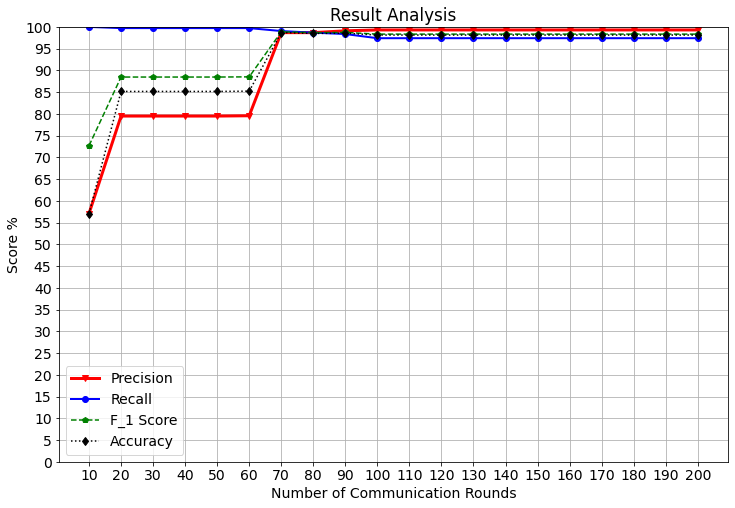

In [46]:
from matplotlib.pyplot import MultipleLocator
plt.title('Result Analysis')
P = np.array(P) 
R = np.array(R)
F1 = np.array(F)
A = np.array(A)
x_axis = np.arange(10,Communication_Rounds,10)
plt.plot(x_axis,P * 100,'rv-', label = 'Precision',linewidth = 3)
plt.plot(x_axis,R * 100, 'bo-', label = 'Recall',linewidth = 2)
plt.plot(x_axis,F1 * 100, 'gp--', label = 'F_1 Score')
plt.plot(x_axis,A * 100, 'kd:', label = 'Accuracy')
plt.legend()
ax=plt.gca()
y_major_locator=MultipleLocator(5)
ax.yaxis.set_major_locator(y_major_locator)
x_major_locator=MultipleLocator(10)
ax.xaxis.set_major_locator(x_major_locator)

plt.ylim((0, 100))
plt.xlabel('Number of Communication Rounds')
plt.ylabel('Score %')
plt.legend()
plt.grid()
plt.show()

In [47]:
np.savetxt('P_C {}.txt'.format(C), P)   # X is an array

np.savetxt('R_C {}.txt'.format(C), R)   # X is an array

np.savetxt('F1_C {}.txt'.format(C), F1)   # X is an array

In [48]:
for i in range(210):
    if (i) % 10 == 0 and i!=0:
        print(i)

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200


In [49]:
anomaly_score = score[-1]
threshold = 1
ind = np.where(anomaly_score >= threshold)
predict_label = np.zeros(anomaly_score.shape[0])
predict_label [ind] =1

In [50]:
precision = precision_score(y_test, predict_label,zero_division = 0)
recall = recall_score(y_test, predict_label,zero_division = 0)
f = f1_score(y_test, predict_label,zero_division = 0)   
acc = accuracy_score(y_test, predict_label)

In [51]:
precision

0.9930451978347942

In [52]:
recall

0.9740701654025584

In [53]:
f

0.983466163891111

In [54]:
acc

0.9813029736567495

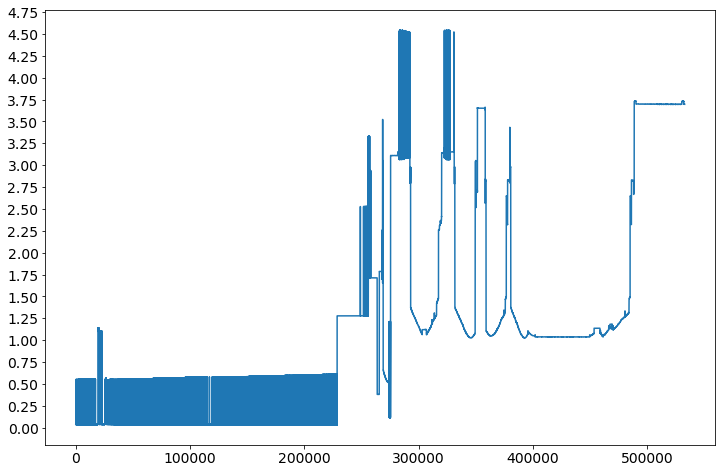

In [55]:
from matplotlib.pyplot import MultipleLocator
ax=plt.gca()
y_major_locator=MultipleLocator(0.25)
ax.yaxis.set_major_locator(y_major_locator)


plt.plot(anomaly_score)

In [56]:
sum(anomaly_score[0:2131247])/2131247

0.28836018194852564

In [57]:
anomaly_score.shape[0]

532812

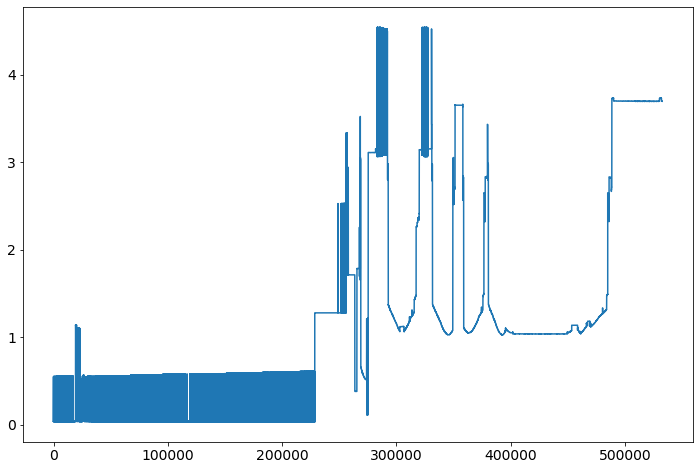

In [58]:
# anomaly_score.hist(bins=10)
plt.plot(anomaly_score[0:2131247])

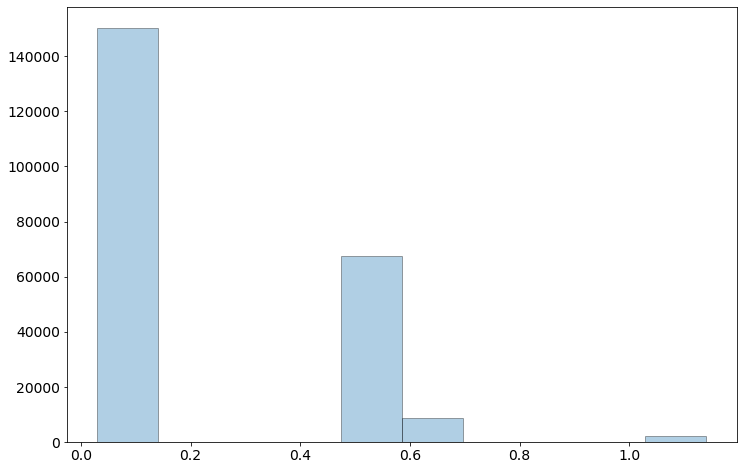

In [59]:
plt.hist(anomaly_score[0:228644], edgecolor='k', alpha=0.35) # 设置直方边线颜色为黑色，不透明度为 0.35
plt.show()


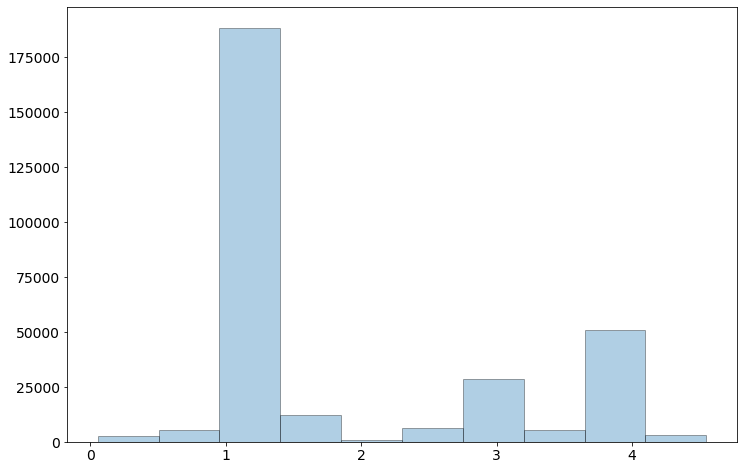

In [60]:
plt.hist(anomaly_score[228644::], edgecolor='k', alpha=0.35) # 设置直方边线颜色为黑色，不透明度为 0.35
plt.show()
